# 04 — Sentiment Model Training
Trains the three-tier ensemble used in backtesting:

| Layer | Model | Input |
|-------|-------|-------|
| Base 1 | Random Forest | TF-IDF + VADER + temporal features |
| Base 2 | Gradient Boosting | same tabular features |
| Base 3 | FinBERT fine-tuned | headline text (up to 512 tokens) |
| Meta | Logistic Regression | base model probability outputs |

Outputs saved to `models/saved_models/`.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp

ROOT   = Path('..')
PROC   = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models' / 'saved_models'
MODELS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC / 'features.csv', parse_dates=['date'])
print(f'Loaded {len(df):,} rows')
df['label_1d'].value_counts(dropna=False)

Loaded 13,649 rows


label_1d
DOWN       5225
UP         5165
NEUTRAL    3244
NaN          15
Name: count, dtype: int64

## 1. Prepare train / test split (time-based)

In [2]:
# Drop rows without labels
df_labeled = df.dropna(subset=['label_1d']).copy()
df_labeled = df_labeled[df_labeled['label_1d'].isin(['UP','DOWN','NEUTRAL'])]
print(f'Labeled rows: {len(df_labeled):,}')

# Time-based split — last 20% of dates = test
cutoff = df_labeled['date'].quantile(0.80)
train_df = df_labeled[df_labeled['date'] <= cutoff].copy()
test_df  = df_labeled[df_labeled['date'] >  cutoff].copy()
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')
print(f'Cutoff date: {cutoff.date()}')

le = LabelEncoder()
y_train = le.fit_transform(train_df['label_1d'])
y_test  = le.transform(test_df['label_1d'])
print('Label classes:', le.classes_)

Labeled rows: 13,634
Train: 10,935  |  Test: 2,699
Cutoff date: 2026-01-26
Label classes: ['DOWN' 'NEUTRAL' 'UP']


## 2. TF-IDF + tabular feature matrix

In [4]:
TABULAR_COLS = ['vader_pos','vader_neg','vader_neu','vader_compound',
                'day_of_week','month','quarter','is_monday','is_friday',
                'is_month_end','is_qtr_end','headline_len']

# Fill any missing tabular cols with 0
for col in TABULAR_COLS:
    if col not in df_labeled.columns:
        df_labeled[col] = 0

# Ensure headline_len exists in train_df and test_df
if 'headline_len' not in train_df.columns:
    train_df['headline_len'] = train_df['combined_text_512'].fillna('').str.len()
if 'headline_len' not in test_df.columns:
    test_df['headline_len'] = test_df['combined_text_512'].fillna('').str.len()

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                        sublinear_tf=True, min_df=3)

X_tfidf_train = tfidf.fit_transform(train_df['combined_text_512'].fillna(''))
X_tfidf_test  = tfidf.transform(test_df['combined_text_512'].fillna(''))

scaler = StandardScaler()
X_tab_train = scaler.fit_transform(train_df[TABULAR_COLS].fillna(0))
X_tab_test  = scaler.transform(test_df[TABULAR_COLS].fillna(0))

X_train = sp.hstack([X_tfidf_train, sp.csr_matrix(X_tab_train)])
X_test  = sp.hstack([X_tfidf_test,  sp.csr_matrix(X_tab_test)])

print(f'Feature matrix — train: {X_train.shape}  test: {X_test.shape}')

Feature matrix — train: (10935, 5012)  test: (2699, 5012)


## 3. Train base models

In [5]:
# ── Random Forest ──
print('Training Random Forest ...')
rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_train_acc = rf.score(X_train, y_train)
rf_test_acc  = rf.score(X_test,  y_test)
print(f'  RF — train: {rf_train_acc:.3f}  test: {rf_test_acc:.3f}')

Training Random Forest ...
  RF — train: 0.635  test: 0.326


In [6]:
# ── Gradient Boosting ──
print('Training Gradient Boosting ...')
gb = GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                 learning_rate=0.05, random_state=42)
gb.fit(X_train.toarray(), y_train)
gb_test_acc = gb.score(X_test.toarray(), y_test)
print(f'  GB — test: {gb_test_acc:.3f}')

Training Gradient Boosting ...
  GB — test: 0.399


## 4. Build meta-learner (stacking ensemble)

In [7]:
# Out-of-fold probabilities for meta training
from sklearn.model_selection import StratifiedKFold

skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_train = np.zeros((len(y_train), 6))   # 3 classes × 2 models

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    Xf_tr, Xf_val = X_train[tr_idx], X_train[val_idx]
    yf_tr         = y_train[tr_idx]

    _rf = RandomForestClassifier(n_estimators=100, max_depth=12,
                                  class_weight='balanced', random_state=42, n_jobs=-1)
    _rf.fit(Xf_tr, yf_tr)
    meta_train[val_idx, :3] = _rf.predict_proba(Xf_val)

    _gb = GradientBoostingClassifier(n_estimators=80, max_depth=4,
                                      learning_rate=0.05, random_state=42)
    _gb.fit(Xf_tr.toarray(), yf_tr)
    meta_train[val_idx, 3:] = _gb.predict_proba(Xf_val.toarray())

    print(f'  Fold {fold} done')

# Test meta features
meta_test = np.hstack([
    rf.predict_proba(X_test),
    gb.predict_proba(X_test.toarray())
])

# Train meta-learner
meta_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
meta_lr.fit(meta_train, y_train)
meta_acc = meta_lr.score(meta_test, y_test)
print(f'\nMeta-learner accuracy: {meta_acc:.3f}')

  Fold 1 done
  Fold 2 done
  Fold 3 done
  Fold 4 done
  Fold 5 done

Meta-learner accuracy: 0.383


## 5. Evaluation

In [8]:
y_pred = meta_lr.predict(meta_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        DOWN       0.43      0.35      0.39      1298
     NEUTRAL       0.18      0.03      0.05       378
          UP       0.36      0.55      0.44      1023

    accuracy                           0.38      2699
   macro avg       0.32      0.31      0.29      2699
weighted avg       0.37      0.38      0.36      2699



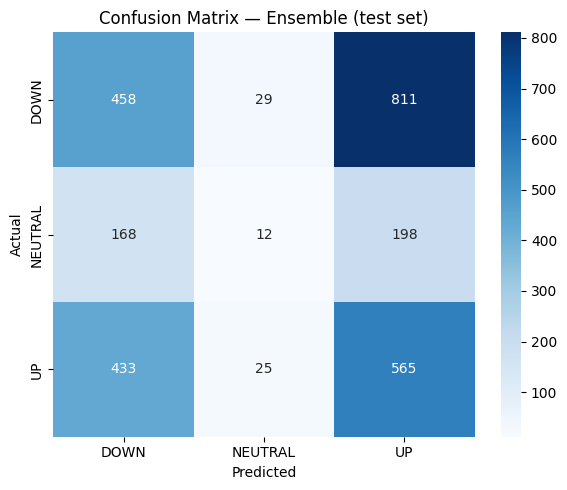

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Ensemble (test set)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'plots' / 'confusion_matrix.png')
plt.show()

## 6. Save models

In [10]:
ensemble_bundle = {
    'rf'        : rf,
    'gb'        : gb,
    'meta_lr'   : meta_lr,
    'tfidf'     : tfidf,
    'scaler'    : scaler,
    'le'        : le,
    'tabular_cols': TABULAR_COLS,
}

with open(MODELS / 'ensemble_stock_predictor.pkl', 'wb') as f:
    pickle.dump(ensemble_bundle, f)

print('✅ Saved ensemble_stock_predictor.pkl')

✅ Saved ensemble_stock_predictor.pkl
